## Задача 1

Реализовать класс для работы с линейной регрессией

In [1]:
import pandas as pd
import numpy as np
import math


class MyLinearRegression:
    """
    Parameters
    ----------
    regularization : {None, 'l1', 'l2', 'l1l2'}, default=None
        Какую регуляризацию добавить к модели. Если значение `None`, то без регуляризации.

    weight_calc : {'matrix', 'gd', 'sgd'}, default='matrix'
        Каким образом вычислять вектор весов: матрично ('matrix'), градиентным спуском ('gd') или стохастическим градиентным спуском ('sgd'). При этом, при 'l1' или 'l1l2' нельзя использовать параметр 'matrix'.

    Attributes
    ----------
    coefs_ : Вектор коэффициентов размера (p, 1), где p — количество признаков.
    intercept_ : Значение коэффициента, отвечающего за смещение
    """

    def __init__(
        self,
        regularization=None,
        weight_calc="matrix",
        lambda_1=None,
        lambda_2=None,
        batch_size=20,
    ):
        if regularization not in [None, "l1", "l2", "l1l2"]:
            raise TypeError(
                f"Параметр regularization не может принимать значение '{regularization}'"
            )
        if weight_calc not in ["matrix", "gd", "sgd"]:
            raise TypeError(
                f"Параметр weight_calc не может принимать значение '{weight_calc}'"
            )
        if regularization in ["l1", "l1l2"] and lambda_1 is None:
            raise TypeError(f"Значение коэффициента регулризации l1 не задано")
        if regularization in ["l2", "l1l2"] and lambda_2 is None:
            raise TypeError(f"Значение коэффициента регулризации l2 не задано")
        if regularization in ["l1", "l1l2"] and weight_calc == "matrix":
            raise ValueError(
                f"Нельзя использовать и регулиризацию (l1,l1l2) и параметр matrix"
            )

        self.regularization = regularization
        self.weight_calc = weight_calc
        self.lambda_1 = lambda_1
        self.lambda_2 = lambda_2
        self.batch_size = batch_size

        self.coefs_ = None
        self.intercept_ = None

    def fit(
        self,
        X: pd.DataFrame,
        y: pd.DataFrame,
        lr: float = 0.01,
        max_iter: int = 1000,
        random_state: int = 42,
    ):
        X_arr = np.array(X)
        y_arr = np.array(y)
        if len(y_arr.shape) > 1:
            y_arr = y_arr.flatten()
        ones_col = np.ones((X_arr.shape[0], 1))
        X_full = np.hstack([ones_col, X_arr])
        n_samples, n_features = X_full.shape
        if self.weight_calc == "matrix":
            self._fit_matrix(X_full, y_arr, n_features)
        else:
            self._fit_gradient(
                X_full, y_arr, n_samples, n_features, lr, max_iter, random_state
            )
        self.coefs_ = self.weights[1:]
        self.intercept_ = self.weights[0]

    def _fit_matrix(self, X, y, n_features):
        if self.regularization == "l2":
            i = np.eye(n_features)
            i[0, 0] = 0
            lhs = X.T @ X + self.lambda_2 * i
            rhs = X.T @ y
            self.weights = np.linalg.solve(lhs, rhs)
        else:
            lhs = X.T @ X
            rhs = X.T @ y
            self.weights = np.linalg.solve(lhs, rhs)

    def _fit_gradient(self, X, y, n_samples, n_features, lr, max_iter, random_state):
        np.random.seed(random_state)
        self.weights = np.random.randn(n_features) * 0.01
        for _ in range(max_iter):
            if self.weight_calc == "gd":
                grad = self._calc_gradient(X, y, self.weights, n_samples)
                self.weights -= lr * grad
            elif self.weight_calc == "sgd":
                indices = np.random.permutation(n_samples)
                X_shuffled = X[indices]
                y_shuffled = y[indices]

                for start in range(0, n_samples, self.batch_size):
                    end = start + self.batch_size
                    X_batch = X_shuffled[start:end]
                    y_batch = y_shuffled[start:end]
                    current_batch_size = X_batch.shape[0]
                    grad = self._calc_gradient(
                        X_batch, y_batch, self.weights, current_batch_size
                    )
                    self.weights -= lr * grad

    def _calc_gradient(self, X, y, w, n):
        predictions = X @ w
        error = predictions - y
        grad = (2 / n) * (X.T @ error)
        w_reg = w.copy()
        w_reg[0] = 0
        if self.regularization in ["l1", "l1l2"]:
            grad += self.lambda_1 * np.sign(w_reg)

        if self.regularization in ["l2", "l1l2"]:
            grad += 2 * self.lambda_2 * w_reg

        return grad

    def predict(self, X: np.array, ss=True):
        X_arr = np.array(X)
        ones_col = np.ones((X_arr.shape[0], 1))
        X_full = np.hstack([ones_col, X_arr])
        full_weights = np.concatenate(([self.intercept_], self.coefs_.flatten()))
        return X_full @ full_weights

    def score(self, X: np.array, y: np.array):
        y_pred = self.predict(X)
        y_true = np.array(y)
        ss_res = np.sum((y_true - y_pred) ** 2)
        ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
        if ss_tot == 0:
            return 0.0
        return 1 - (ss_res / ss_tot)

Используя датасет про автомобили (целевой признак — price), сравнить (качество, скорость обучения и предсказания, важность признаков) модели `MyLinearRegression` с различными гиперпараметрами, сделать выводы. На этом же датасете сравнить модель `MyLinearRegression` с библиотечной реализацией из `sklearn`, составить таблицу(ы) (графики) результатов сравнения (качество, скорость обучения и предсказания, важность признаков).

In [2]:
import pandas as pd
file_path = "Used_fiat_500_in_Italy_dataset.csv"
data_frame = pd.read_csv(file_path)
print(data_frame.head())

    model  engine_power transmission  age_in_days      km  previous_owners  \
0     pop            69       manual         4474   56779                2   
1  lounge            69       manual         2708  160000                1   
2  lounge            69    automatic         3470  170000                2   
3   sport            69       manual         3288  132000                2   
4   sport            69       manual         3712  124490                2   

         lat       lon  price  
0  45.071079   7.46403   4490  
1  45.069679   7.70492   4500  
2  45.514599   9.28434   4500  
3  41.903221  12.49565   4700  
4  45.532661   9.03892   4790  


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
X = data_frame.drop("price",axis = 1)
y = data_frame["price"]
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object']).columns
X_num = X[numerical_features].copy()
X_cat = X[categorical_features].copy()
transformed_data = {}
mean_values = X_num.mean()
# print(f"Вычисленные средние: {mean_values.to_dict()}")
X_num_filled = X_num.fillna(mean_values)
X_num_transformed = X_num_filled.values
transformed_data['num'] = X_num_transformed
X_cat_filled = X_cat.fillna('missing')
X_cat_transformed = pd.get_dummies(X_cat_filled, prefix=categorical_features, drop_first=False)
X_cat_transformed_arr = X_cat_transformed.values
transformed_data['cat'] = X_cat_transformed_arr
X_processed_numpy = np.hstack([
    transformed_data['num'], 
    transformed_data['cat']
])
X_train, X_test, y_train, y_test = train_test_split(X_processed_numpy,y.to_numpy(),test_size=0.2,random_state=42)
print(X_train[:2])
print(type(y_train))



[[6.90000000e+01 3.97000000e+02 1.83240000e+04 2.00000000e+00
  4.54361000e+01 8.88786983e+00 1.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00 0.00000000e+00 1.00000000e+00]
 [6.90000000e+01 4.16900000e+03 8.19000000e+04 2.00000000e+00
  4.54432716e+01 1.02302103e+01 1.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00 0.00000000e+00 1.00000000e+00]]
<class 'numpy.ndarray'>


In [4]:
import matplotlib.pyplot as plt
import time
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
def evaluate(model, X_train, y_train, X_test, y_test):
    t0 = time.time()
    model.fit(X_train, y_train)
    fit_time = time.time() - t0

    t0 = time.time()
    y_pred = model.predict(X_test)
    pred_time = time.time() - t0

    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    return mse, r2, fit_time, pred_time


mse_sk,r2_sk,fit_time_sk,pred_time_sk = evaluate(LinearRegression(),X_train,y_train,X_test,y_test)
print("MSE_sk: " ,mse_sk)
print("R2_sk: " , r2_sk)
print("fit_time: ",fit_time_sk )
print("pred_time_sk: ",pred_time_sk)

model_matrix = MyLinearRegression(
    regularization="l2", weight_calc="matrix", lambda_2=0.1
)
start = time.time()
model_matrix.fit(X_train, y_train)
end = time.time()

print(f"R2_sk: {model_matrix.score(X_test, y_test):.4f}")
print(f"Intercept: {model_matrix.intercept_:.2f}")
print(f"Time: {end-start}")


MSE_sk:  538361.6528625513
R2_sk:  0.8945337093911594
fit_time:  0.00919795036315918
pred_time_sk:  0.0
R2_sk: 0.8945
Intercept: 4596.19
Time: 0.0020351409912109375


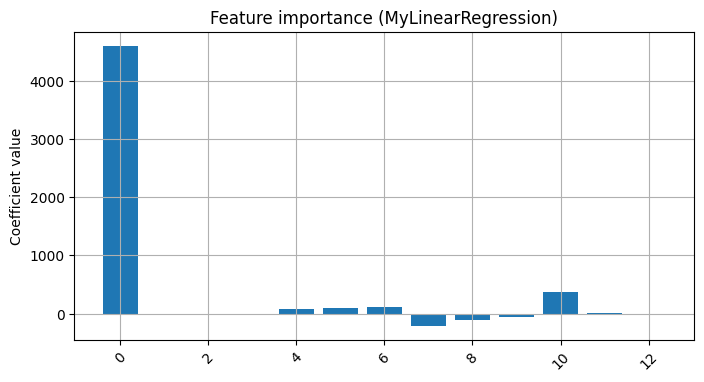

In [5]:
coef = model_matrix.weights  # веса MyLinearRegression

plt.figure(figsize=(8, 4))
plt.bar(range(len(coef)),coef)
plt.xticks(rotation=45)
plt.ylabel("Coefficient value")
plt.title("Feature importance (MyLinearRegression)")
plt.grid(True)
plt.show()

## Задача 2

[Соревнование на Kaggle](https://kaggle.com/competitions/yadro-regression-2025)